In [1]:
import os
import random
import numpy as np
from ase.io import read
from quests.descriptor import get_descriptors
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from adjustText import adjust_text
import matplotlib

## Preparing to analyze results

In [ ]:
# seeing which structures correspond to which descriptors
dset_y = read("/data/christine/quests/mptrj/mptrj_subset_500.extxyz", index=":")
# dset_y = read("spice/spice_set_10_each.extxyz", index=":")

k, cutoff = 32, 5.0
result = []

for i, structure in tqdm(enumerate(dset_y)):
    y = get_descriptors([structure], k=k, cutoff=cutoff)
    result.extend([i] * len(y))

len(result)

In [19]:
subset_indices = np.array(result)
np.save("mptrj/mptrj_subset_descriptor_indices_new.npy", subset_indices)

In [20]:
dset_y = read("/home/christine/quests/mptrj/mptrj_subset_new.extxyz", index=":")
print(len(dset_y)) # not the same length as the descriptors

500


## Analyzing results

In [2]:
dH = np.load('/data/christine/quests/mptrj/mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

(161035,)

In [3]:
subset_indices = np.load("/data/christine/quests/mptrj/mptrj_subset_descriptor_indices.npy")
subset_indices.shape

(161035,)

In [4]:
# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(5318,)

In [5]:
# using the max
# Use np.maximum.reduceat to find the max per group
sorted_indices = np.argsort(subset_indices)
sorted_values = dH[sorted_indices]
sorted_indices = subset_indices[sorted_indices]

# Get unique indices and positions where they change
unique_indices, start_idx = np.unique(sorted_indices, return_index=True)
max_values = np.maximum.reduceat(sorted_values, start_idx)

# Create a full array with max values at the correct positions
max_result = np.zeros(5318)
max_result[unique_indices] = max_values

In [6]:
# need to get the force arrays to have only the correct 500 structures
random.seed(88)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

# Example usage
data_dir = "/data/shared/MPTrj/original"
sample_size = 500  # Change to the desired number of files

random_files = random_sample_from_directory(data_dir, sample_size)

num_structures_per_file = []
for file in random_files:
    atoms = read(os.path.join(data_dir, file), index=":")
    num_structures_per_file.append(len(atoms))

sum(num_structures_per_file)

5318

In [7]:
# doing this in one cell for all of the models
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD",  "eqV2(OMat)"]
#     # "MACE-MPA", "ORB"
# ]

force_errors_dict = {}

for i, model_name in enumerate(model_names):
    fname = f'../mlip-arena/force_errors/{model_name}_force_errors.npy'
    force_errors = np.load(fname, allow_pickle=True)
    
    last_forces = []
    curr_index = 0
    for item in num_structures_per_file:
        curr_index += item
        last_forces.append(force_errors[curr_index-1])

    print(curr_index)  # should be 5318
    print(len(last_forces))
    
    force_errors_dict[model_name] = last_forces

5318
500
5318
500
5318
500
5318
500
5318
500
5318
500
5318
500
5318
500


(5318,)
(5318,)
(5318,)
(5318,)
(5318,)
(5318,)
(5318,)
(5318,)


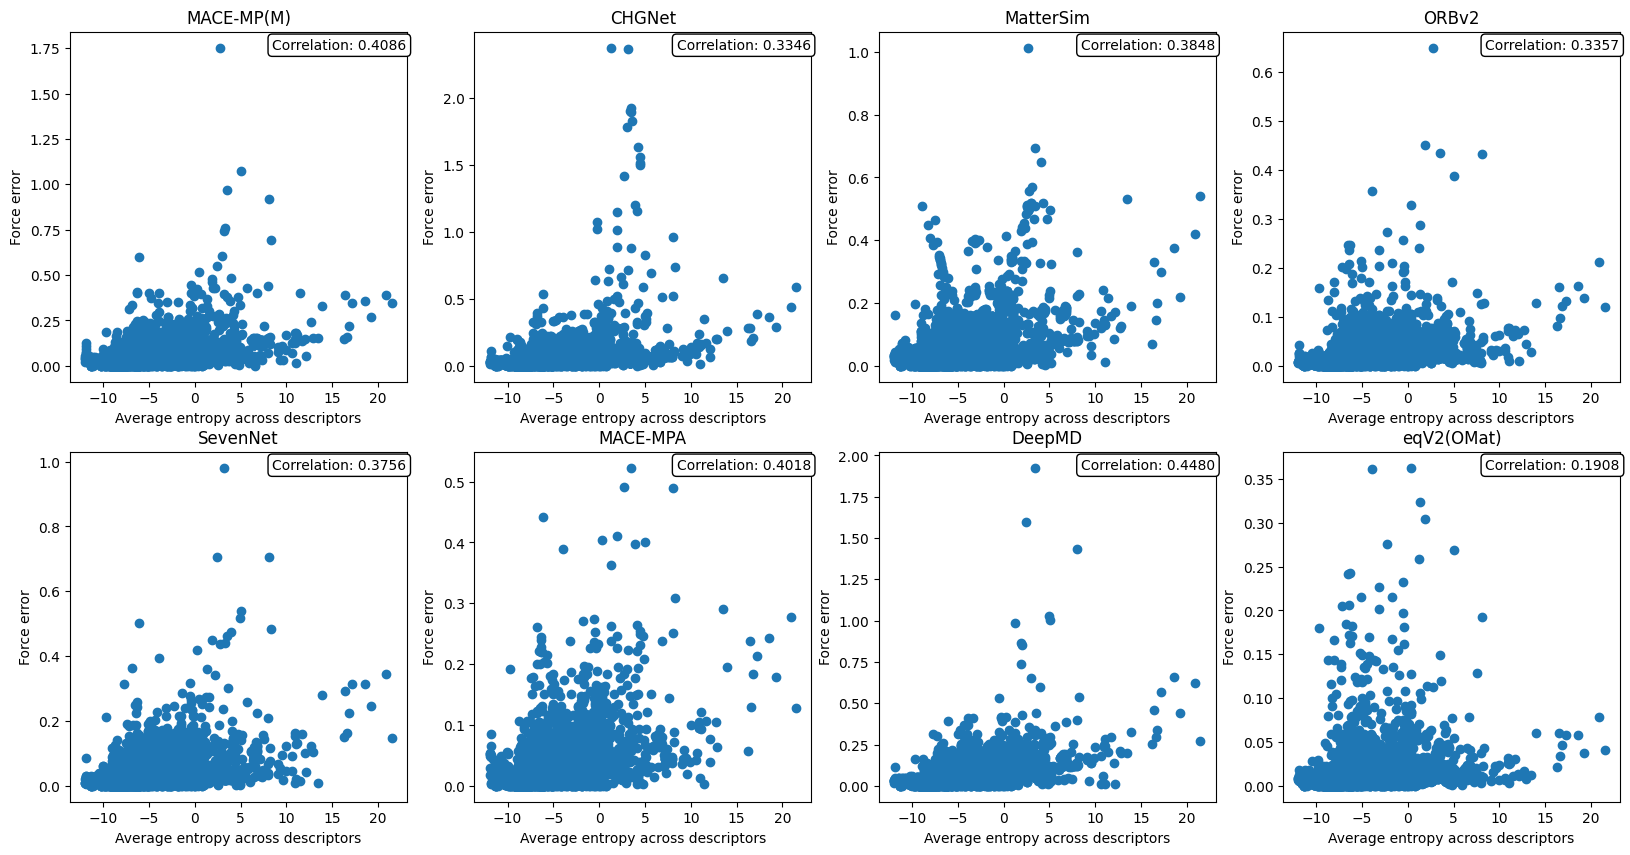

In [8]:
# doing this in one cell for all of the models
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD",  "eqV2(OMat)"]
#     # "MACE-MPA", "ORB"
# ]

# create a subplot for each model
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    fname = f'../mlip-arena/force_errors/{model_name}_force_errors.npy'
    force_errors = np.load(fname, allow_pickle=True)
    # force_errors = np.array(force_errors_dict[model_name])
    
    # convert this list of arrays into a 1d array
    # force_errors = np.concatenate(force_errors)

    # using sum of each structure's descriptors' entropy
    sum_entropy_per_index = np.bincount(subset_indices, weights=dH)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)
    print(avg_entropies.shape)
    
    # get rid of force error outliers
    mask = force_errors <= 5
    avg_entropies = avg_entropies[mask]
    force_errors = force_errors[mask]

    # produce a scatter plot of avg_values vs. force_errors
    axs.flat[i].scatter(avg_entropies, force_errors)

    # label axes on the subplots
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Force error")
    axs.flat[i].set_title(f"{model_name}")

    # get the correlation of the scatter plot and label it on the plot
    corr, p_value = pearsonr(avg_entropies, force_errors) # \n p-value: {p_value:.4f}
    axs.flat[i].text(0.6, 0.95, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

/home/christine/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/christine/.local/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


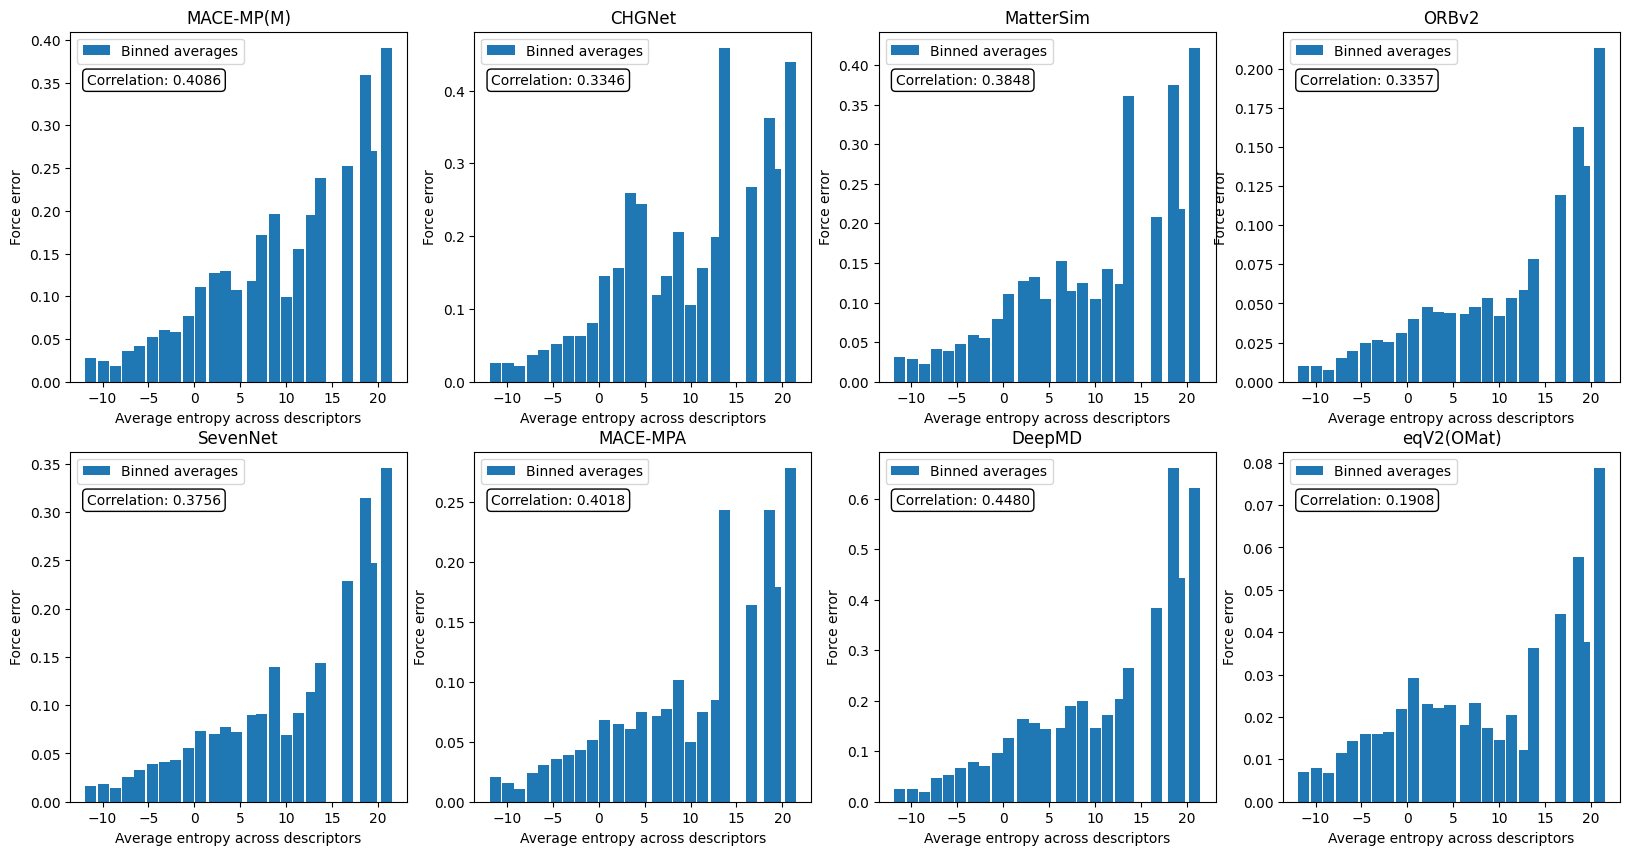

In [9]:
# doing this in one cell for all of the models
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD", "eqV2(OMat)"]
#     "eqV2(OMat)", # no permission
#     # "MACE-MPA", "DeepMD", "ORB"
# ]

# Define the number of bins
num_bins = 25

# create a subplot for each model
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    fname = f'../mlip-arena/force_errors/{model_name}_force_errors.npy'
    force_errors = np.load(fname)
    # force_errors = np.array(force_errors_dict[model_name])

    # using sum of each structure's descriptors' entropy
    sum_entropy_per_index = np.bincount(subset_indices, weights=dH)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)
    
    # get rid of force error outliers
    mask = force_errors <= 5
    avg_entropies = avg_entropies[mask]
    force_errors = force_errors[mask]

    # Compute bin edges
    bin_edges = np.linspace(min(avg_entropies), max(avg_entropies), num_bins + 1)

    # Assign each x-value to a bin
    bin_indices = np.digitize(avg_entropies, bins=bin_edges) - 1  # -1 to make it 0-based

    # Compute the average y-values for each bin
    binned_x = []
    binned_y = []

    for j in range(num_bins):
        bin_mask = bin_indices == j  # Select data points in this bin
        if np.any(mask):  # Avoid empty bins
            binned_x.append(np.mean(avg_entropies[bin_mask]))  # Bin center
            binned_y.append(np.mean(force_errors[bin_mask]))   # Average y-value

    # Plot the binned data
    axs.flat[i].bar(binned_x, binned_y, width=(bin_edges[1] - bin_edges[0]) * 0.9, align='center', label="Binned averages")

    # Label axes and title
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Force error")
    axs.flat[i].set_title(f"{model_name}")
    axs.flat[i].legend()

    # get the correlation of the scatter plot and label it on the plot
    corr, p_value = pearsonr(avg_entropies, force_errors) # \n p-value: {p_value:.4f}
    axs.flat[i].text(0.05, 0.85, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

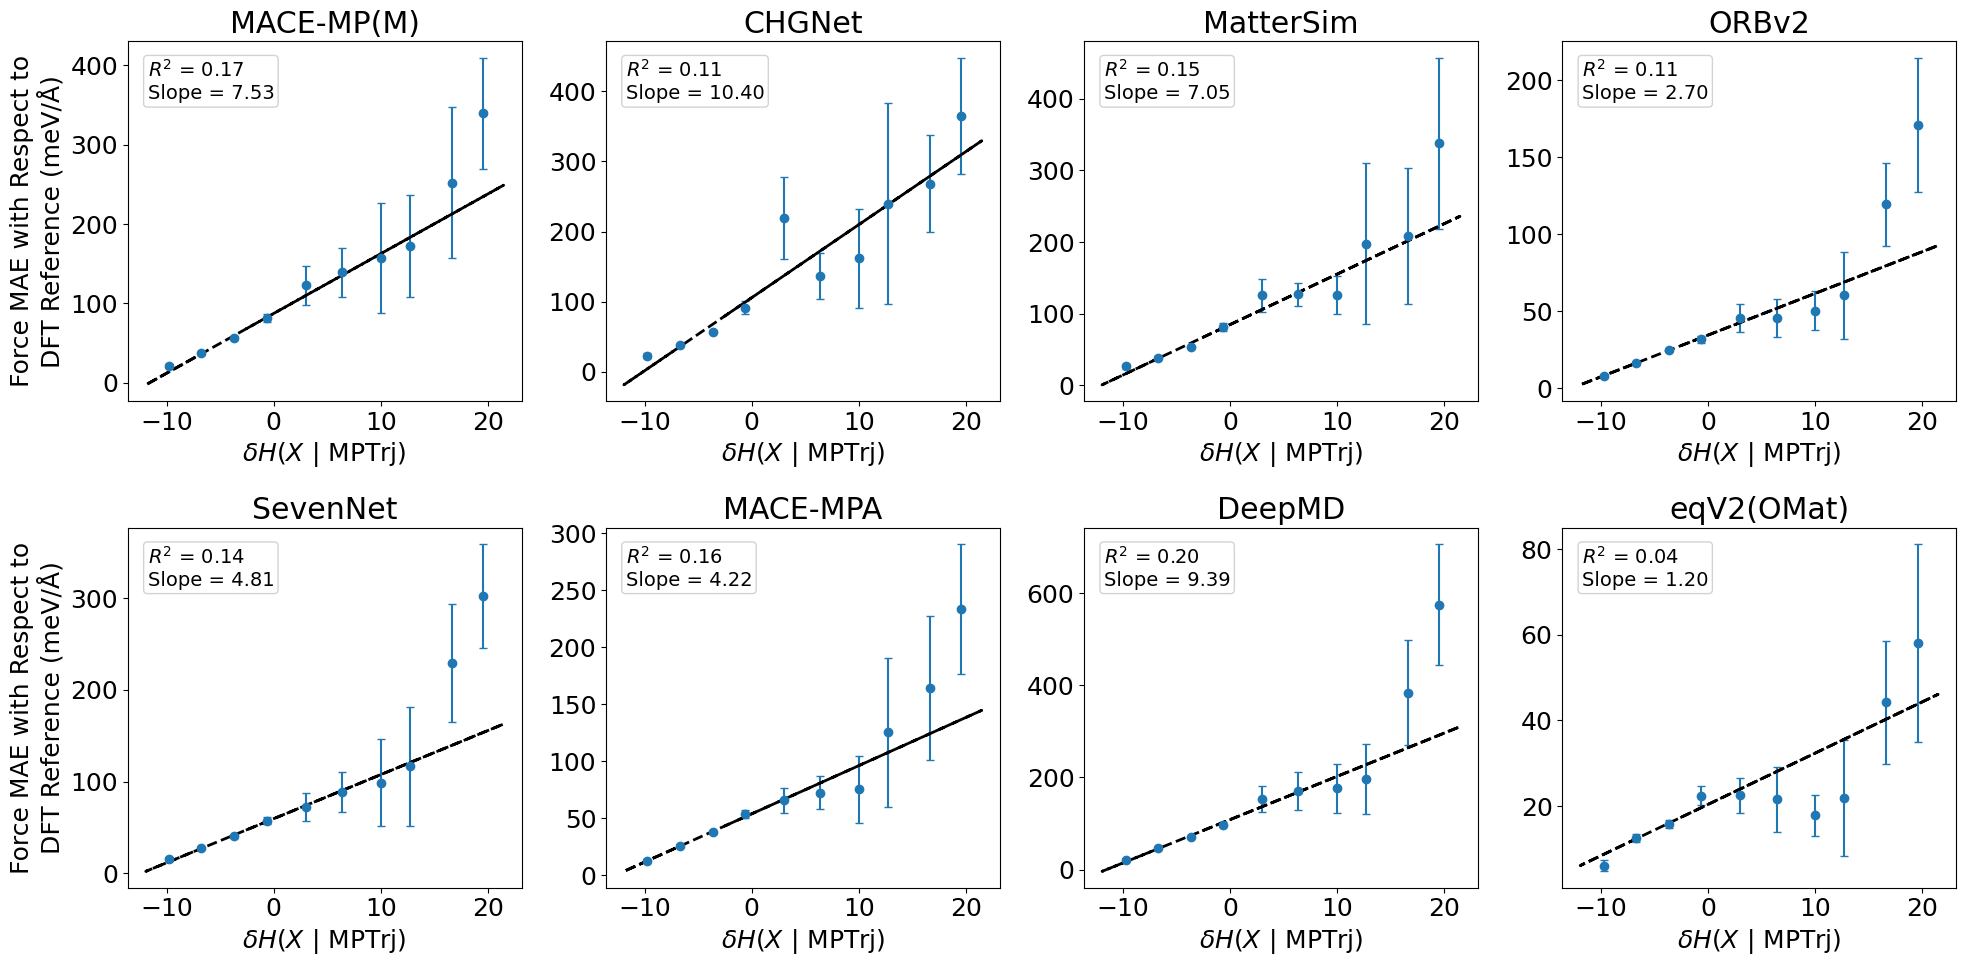

In [16]:
matplotlib.rcParams.update({'font.size': 18})

model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2",
    "SevenNet", "MACE-MPA", "DeepMD", "eqV2(OMat)"
]

num_bins = 10

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for model_num, model_name in enumerate(model_names):
    fname = f'../mlip-arena/force_errors/{model_name}_force_errors.npy'
    force_errors = np.load(fname)

    sum_entropy_per_index = np.bincount(subset_indices, weights=dH)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

    mask = force_errors <= 5
    avg_entropies = avg_entropies[mask]
    force_errors = force_errors[mask] * 1000

    bin_edges = np.linspace(min(avg_entropies), max(avg_entropies), num_bins + 1)
    bin_indices = np.digitize(avg_entropies, bins=bin_edges) - 1

    binned_x = []
    binned_y = []
    binned_err = []

    for j in range(num_bins):
        bin_mask = bin_indices == j
        if np.any(bin_mask):
            bin_x = avg_entropies[bin_mask]
            bin_y = force_errors[bin_mask]
            binned_x.append(np.mean(bin_x))
            binned_y.append(np.mean(bin_y))

            # Use normal approximation for 95% CI
            n = len(bin_y)
            if n > 1:
                ci = 1.96 * (np.std(bin_y, ddof=1) / np.sqrt(n))
            else:
                print("n = 1")
                ci = 0.0
            binned_err.append(ci)

    ax = axs.flat[model_num]
    ax.errorbar(binned_x, binned_y, yerr=binned_err, fmt='o', # color='royalblue',
                capsize=3, markersize=6)

    ax.set_xlabel(r"$\delta H (X\ |\ \mathrm{MPTrj})$")
    if model_num == 0 or model_num == 4:
        ax.set_ylabel("Force MAE with Respect to\nDFT Reference (meV/Å)")
    ax.set_title(f"{model_name}")
    
    # corr, p_value = pearsonr(avg_entropies, force_errors)
    # ax.text(0.05, 0.9, f"Correlation: {corr:.4f}", transform=ax.transAxes,
    #         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    
    # Line of best fit with r^2
    slope, intercept = np.polyfit(avg_entropies, force_errors, 1)
    line = slope * avg_entropies + intercept
    ax.plot(avg_entropies, line, color='black', linestyle='--', linewidth=2)
    # Calculate Pearson r and R^2
    r, p = pearsonr(avg_entropies, force_errors)
    r_squared = r**2
    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r_squared:.2f}\nSlope = {slope:.2f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        color='black',
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.2')
    )

plt.tight_layout()
plt.savefig("force_err_dH.pdf", bbox_inches="tight")
plt.show()

## Getting energy conservation from simulations vs entropy

In [7]:
subset_50 = []
with open('../mlip-arena/mptrj_subset_50_ids.txt', 'r') as f:
    for i, line in enumerate(f):
        atoms = read(line.strip())
        subset_50.append(atoms)

len(subset_50)

50

In [8]:
# check that the atoms that you get from just reading the file is the LAST one that you get when you read using index=":"
checks = []
with open('../mlip-arena/mptrj_subset_50_ids.txt', 'r') as f:
    for i, line in enumerate(f):
        atoms = read(line.strip())
        atoms2 = read(line.strip(), index=":")
        checks.append(atoms == atoms2[-1])
print(sum(checks))

50


In [5]:
# from before, copied code
dH = np.load('mptrj/mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

subset_indices = np.load("mptrj/mptrj_subset_descriptor_indices.npy")

# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(5318,)

In [6]:
# get the entropy for these structures given that they are the last ones from the other type of reading
dset_y = read("mptrj/mptrj_subset_500.extxyz", index=":")
len(dset_y)

5318

In [9]:
# get a subset of mptrj
random.seed(88)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

# Example usage
data_dir = "/data/shared/MPTrj/original"
sample_size = 500  # Change to the desired number of files

random_files = random_sample_from_directory(data_dir, sample_size)

num_structures_per_file = []
for file in random_files:
    atoms = read(os.path.join(data_dir, file), index=":")
    num_structures_per_file.append(len(atoms))

sum(num_structures_per_file)

5318

In [10]:
# now, extract the items from avg_entropies that correspond to the last structure per file
last_entropies = []
curr_index = 0
for item in num_structures_per_file:
    curr_index += item
    last_entropies.append(avg_entropies[curr_index-1])

print(curr_index)  # should be 5318
len(last_entropies)

5318


500

In [11]:
# we only ran simulations on every 10th of these, and we also excluded structures 4, 9, and 41
sim_entropies = last_entropies[::10]
sim_entropies = np.delete(sim_entropies, [4, 9, 41])
len(sim_entropies)

47

In [12]:
# check the trajectories to see whether they are stable for each model
thresh = 2
sim_dir = '/home/christine/mlip-arena/simulations'
sim_folders = sorted(os.listdir(sim_dir))
in_thresh = {folder: [] for folder in sim_folders}
out_thresh = {folder: [] for folder in sim_folders}
for folder in sim_folders:
    if "DeepMD" in folder:
        continue
    for traj_file in sorted(os.listdir(os.path.join(sim_dir, folder))):
        traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
        
        # max distance between atoms at the beginning
        val_i = np.max(np.abs(np.roll(traj[0].get_positions(), 1, axis=0) - traj[0].get_positions()))
        
        # max distance between atoms at the end
        val_f = np.max(np.abs(np.roll(traj[-1].get_positions(), 1, axis=0) - traj[-1].get_positions()))
        
        # check if there's a significant difference between these two
        diff = abs(val_i - val_f)
        if diff < thresh:
            in_thresh[folder].append(traj_file)
        else:
            out_thresh[folder].append(traj_file)
    print(f"done with {folder}")

print("IN THRESH")
for key, value in in_thresh.items():
    print(f"{key}: {len(value)}")
print("\nOUT THRESH")
for key, value in out_thresh.items():
    print(f"{key}: {len(value)}")

done with CHGNet_MPTrj_sims_supercell_1000K
done with EquiformerV2(OC20)_OC20_sims_supercell_1000K
done with MACE-MP(M)_MPTrj_sims_supercell_1000K
done with MACE-MPA_MPTrj_sims_supercell_1000K
done with MACE-OFF(M)_spice_sims_supercell_1000K
done with MatterSim_MPTrj_sims_supercell_1000K
done with ORBv2_MPTrj_sims_supercell_1000K
done with SevenNet_MPTrj_sims_supercell_1000K
done with eSCN(OC20)_OC20_sims_supercell_1000K
done with eqV2(OMat)_MPTrj_sims_supercell_1000K
IN THRESH
CHGNet_MPTrj_sims_supercell_1000K: 42
DeepMD_MPTrj_sims_supercell_1000K: 0
EquiformerV2(OC20)_OC20_sims_supercell_1000K: 9
MACE-MP(M)_MPTrj_sims_supercell_1000K: 41
MACE-MPA_MPTrj_sims_supercell_1000K: 40
MACE-OFF(M)_spice_sims_supercell_1000K: 1
MatterSim_MPTrj_sims_supercell_1000K: 42
ORBv2_MPTrj_sims_supercell_1000K: 40
SevenNet_MPTrj_sims_supercell_1000K: 42
eSCN(OC20)_OC20_sims_supercell_1000K: 23
eqV2(OMat)_MPTrj_sims_supercell_1000K: 41

OUT THRESH
CHGNet_MPTrj_sims_supercell_1000K: 5
DeepMD_MPTrj_sims_su

In [13]:
# sim_entropies will be the x-axis for the simulation scatter plots. now we need to get the energy conservation values
model_names = [
    "MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "eqV2(OMat)"]
#     "eqV2(OMat)", "DeepMD", "ORB"

energy_cons = {model_name: [] for model_name in model_names}
entropies = {model_name: sim_entropies[:] for model_name in model_names}

for model_name in model_names:
    dir_name = f"../mlip-arena/simulations/{model_name}_MPTrj_sims_supercell_1000K"
    for i, file in enumerate(sorted(os.listdir(dir_name))):
        # check to make sure they are stable
        if file not in in_thresh[f'{model_name}_MPTrj_sims_supercell_1000K'] or np.isnan(entropies[model_name][i]):
            entropies[model_name][i] = np.nan # set entropy to nan, and remove the nan elements later so we don't get indexing errors in the loop
        else:
            traj = read(os.path.join(dir_name, file), index=":")
            # print(len(traj))
            atoms_i = traj[0]
            atoms_f = traj[-1]
            dE = atoms_f.get_total_energy() - atoms_i.get_total_energy()
            energy_cons[model_name].append(dE)
    deleted = np.delete(entropies[model_name], np.where(np.isnan(entropies[model_name])))
    assert(len(energy_cons[model_name]) == len(deleted))

# print the average energy conservation for each model
for model_name in model_names:
    print(f"Average energy conservation for {model_name}: {np.mean(energy_cons[model_name])}")

Average energy conservation for MACE-MP(M): 0.04864223533982057
Average energy conservation for CHGNet: 0.08139737995179669
Average energy conservation for MatterSim: 0.03706637254099433
Average energy conservation for ORBv2: 39.246434729828856
Average energy conservation for SevenNet: 0.032017111483821026
Average energy conservation for MACE-MPA: 0.032038610741722096
Average energy conservation for eqV2(OMat): 6.932212838551454


In [14]:
idxs_to_remove = {}
for model_name in model_names:
    idxs_to_remove[model_name] = np.where(np.isnan(entropies[model_name]))[0]
idxs_to_remove

{'MACE-MP(M)': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'CHGNet': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'MatterSim': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'ORBv2': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'SevenNet': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'MACE-MPA': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'eqV2(OMat)': array([ 2, 10, 15, 23, 25, 33, 34, 45])}

In [29]:
# remove nan elements
for model_name in model_names:
    entropies[model_name] = np.delete(entropies[model_name], np.where(np.isnan(entropies[model_name])))

In [20]:
for model_name in model_names:
    print(model_name)
    print(len(entropies[model_name]), len(energy_cons[model_name]))
    print()

MACE-MP(M)
39 39

CHGNet
39 39

MatterSim
39 39

ORBv2
39 39

SevenNet
39 39

MACE-MPA
39 39

eqV2(OMat)
39 39



In [21]:
# this is before removing the unstable structures from simulation results
# Average energy conservation for MACE-MP(M): 0.04240042215407444
# Average energy conservation for CHGNet: 0.13607068302416883
# Average energy conservation for MatterSim: 0.030349755709052833
# Average energy conservation for ORBv2: 58.79122831217706
# Average energy conservation for SevenNet: 0.024102508448377653
# Average energy conservation for MACE-MPA: 0.025932587166430057
# Average energy conservation for eqV2(OMat): 8.563859301332842

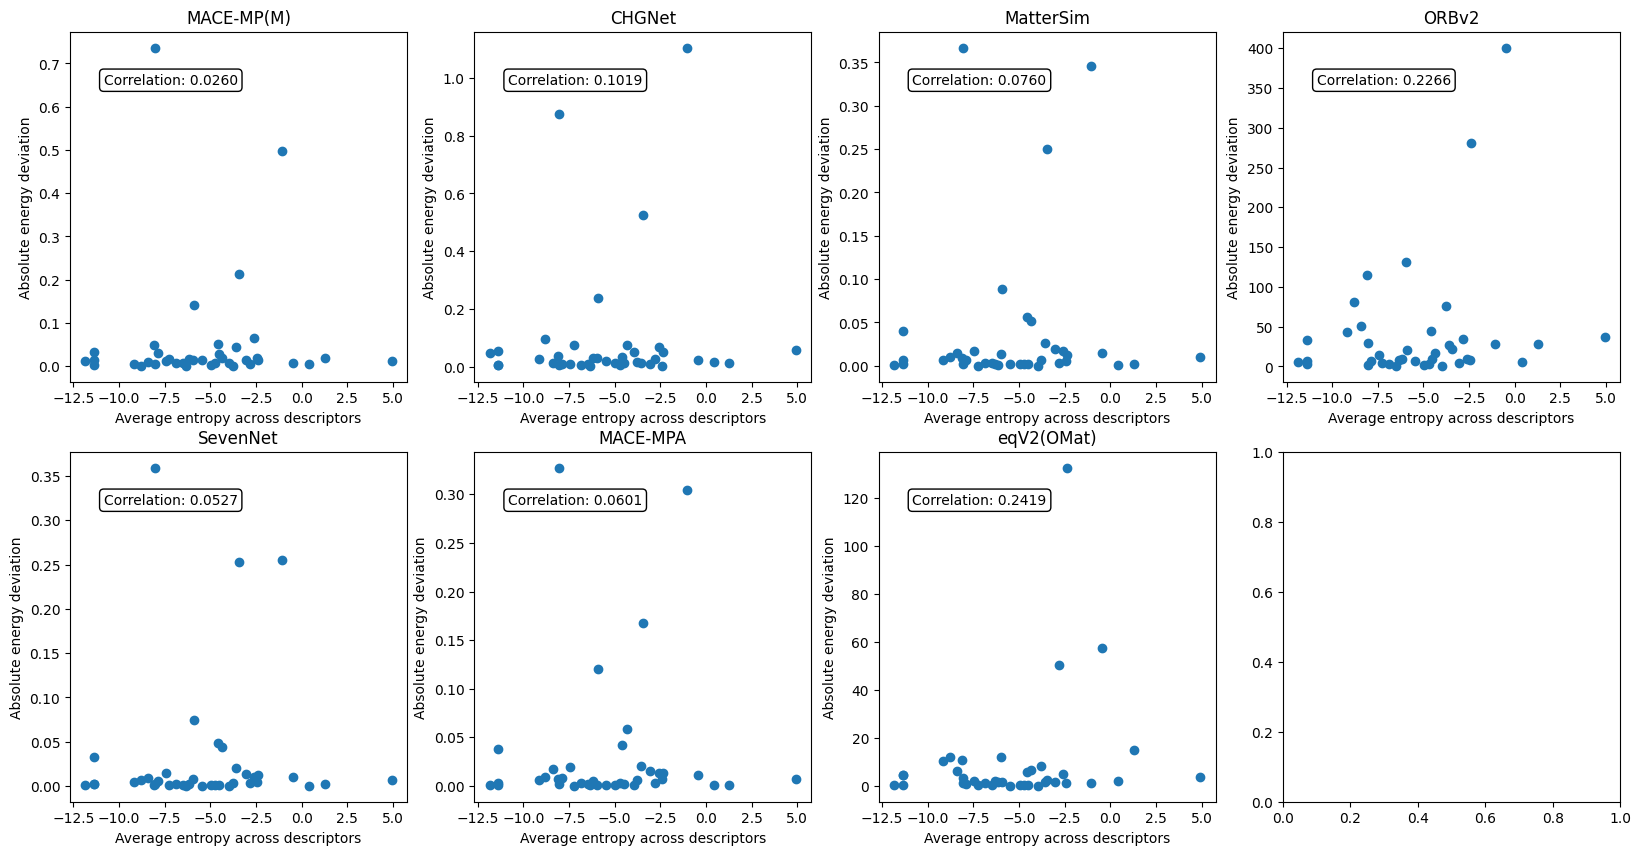

In [22]:
# now we make the scatter plots
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, model_name in enumerate(model_names):
    abs_dev = np.abs(energy_cons[model_name])
    axs.flat[i].scatter(entropies[model_name], abs_dev)
    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Absolute energy deviation")
    axs.flat[i].set_title(f"{model_name}")

    corr, p_value = pearsonr(entropies[model_name], abs_dev)
    axs.flat[i].text(0.1, 0.85, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

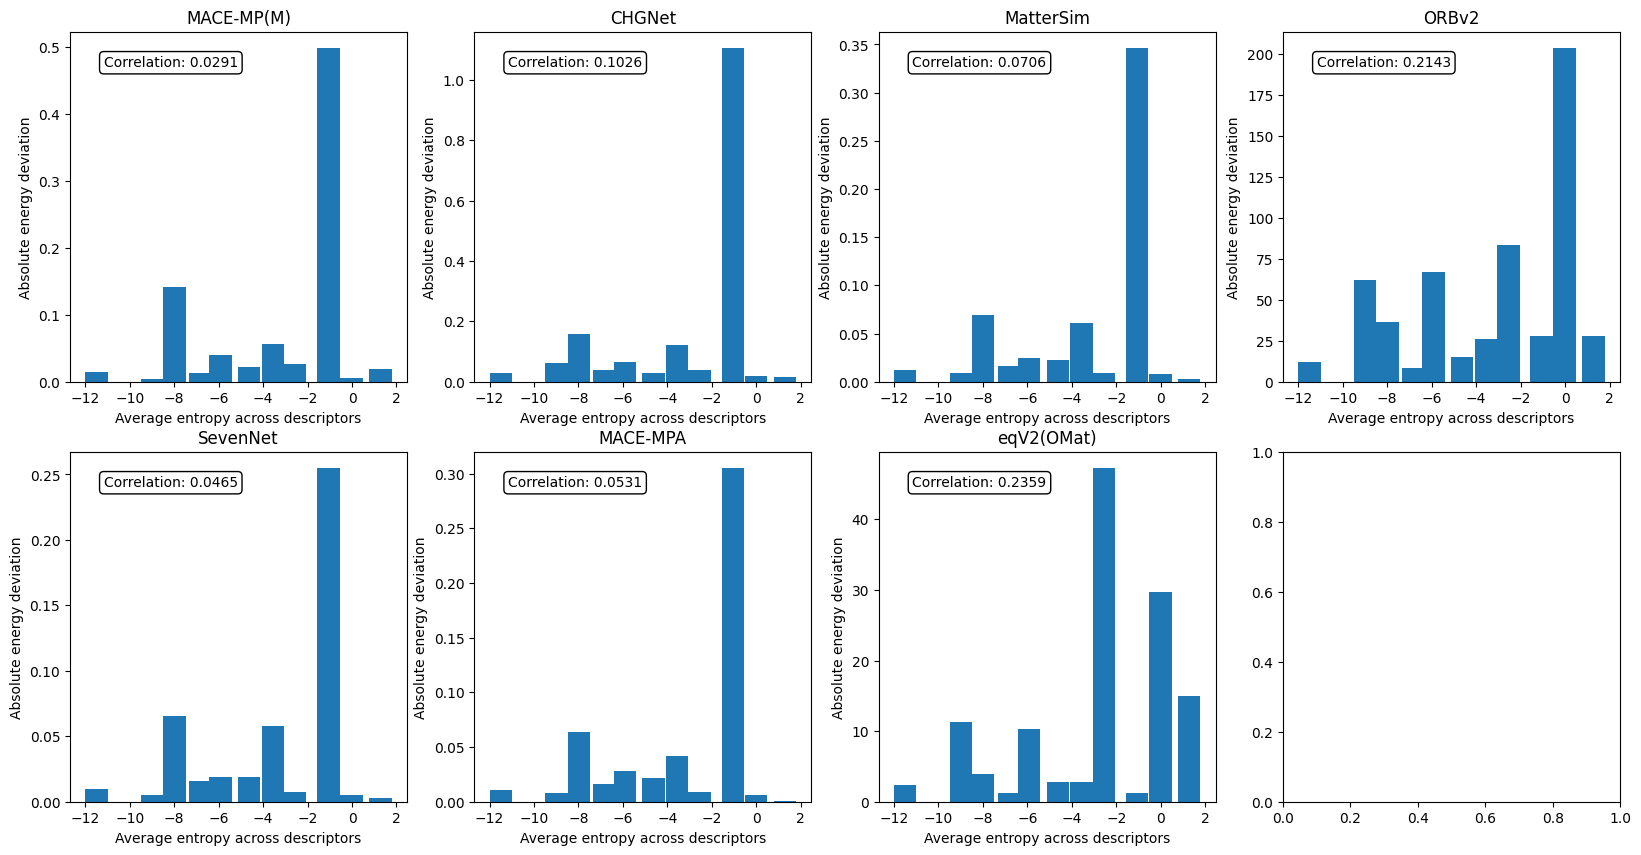

In [21]:
# now we make the binned bar plots
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
num_bins = 15  # or however many bins you want

for i, model_name in enumerate(model_names):
    energy_vals = np.abs(energy_cons[model_name])
    
    # Bin the entropies
    bin_edges = np.linspace(min(entropies[model_name]), max(entropies[model_name]), num_bins + 1)
    bin_indices = np.digitize(entropies[model_name], bins=bin_edges) - 1  # -1 for 0-based indexing

    binned_x = []
    binned_y = []

    for j in range(num_bins):
        mask = bin_indices == j
        if np.any(mask):
            binned_x.append(np.mean(entropies[model_name][mask]))
            binned_y.append(np.mean(energy_vals[mask]))

    axs.flat[i].bar(
        binned_x, binned_y,
        width=(bin_edges[1] - bin_edges[0]) * 0.9,
        align='center',
        label="Binned averages"
    )

    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Absolute energy deviation")
    axs.flat[i].set_title(f"{model_name}")

    # correlation from raw data (not binned)
    corr, p_value = pearsonr(entropies[model_name], energy_vals)
    axs.flat[i].text(0.1, 0.9, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))


In [25]:
for model_name in model_names:
    curr_energy_cons = np.array(energy_cons[model_name])
    # print indices for which curr_energy_cons is greater than 5
    num = 0.4
    indices = np.where(curr_energy_cons > num)[0]
    print(f"Indices for {model_name} where curr_energy_cons > {num}: {indices}")
    
    # # print the corresponding values of sim_entropies
    # print(f"Corresponding values of sim_entropies: {sim_entropies[indices]}")
    # # print the corresponding values of curr_energy_cons
    # print(f"Corresponding values of curr_energy_cons: {curr_energy_cons[indices]}")
    # print()

Indices for MACE-MP(M) where curr_energy_cons > 0.4: [23 35]
Indices for CHGNet where curr_energy_cons > 0.4: [ 2 23 35]
Indices for MatterSim where curr_energy_cons > 0.4: []
Indices for ORBv2 where curr_energy_cons > 0.4: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 38]
Indices for SevenNet where curr_energy_cons > 0.4: []
Indices for MACE-MPA where curr_energy_cons > 0.4: []
Indices for eqV2(OMat) where curr_energy_cons > 0.4: [ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 16 17 18 20 21 22 23 24 25 26
 28 30 31 32 33 34 35 36 38]


In [38]:
# Indices for MACE-MP(M) where curr_energy_cons > 0.4: [25 37]
# Indices for CHGNet where curr_energy_cons > 0.4: [ 2 25 37]
# Indices for MatterSim where curr_energy_cons > 0.2: [ 2 25 37]
# Indices for ORBv2 where curr_energy_cons > 250: [ 3 12]
# Indices for SevenNet where curr_energy_cons > 0.2: [ 2 25 37]
# Indices for MACE-MPA where curr_energy_cons > 0.2: [25 37]
# Indices for eqV2(OMat) where curr_energy_cons > 100: [12]

In [38]:
dir_name = f"../mlip-arena/simulations/CHGNet_MPTrj_sims_supercell_1000K"
sorted(os.listdir(dir_name))[42]

'49_1196814.traj'

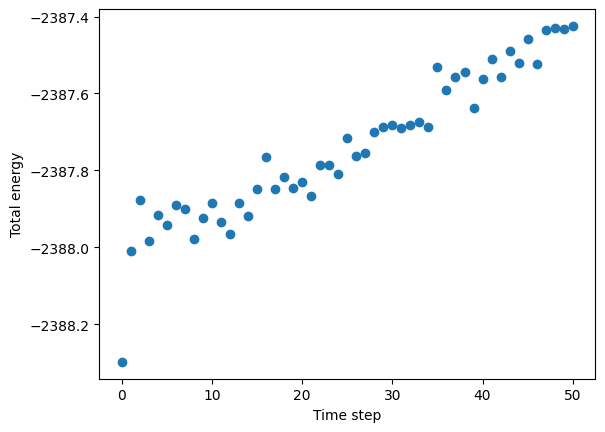

In [42]:
dir_name = f"../mlip-arena/simulations/CHGNet_MPTrj_sims_supercell_1000K"
files = sorted(os.listdir(dir_name))
atoms = files[42]

traj = read(os.path.join(dir_name, atoms), index=":")

# generate a plot of the atoms total energy along the trajectory
plt.scatter(np.arange(len(traj)), [traj[i].get_total_energy() for i in range(len(traj))])
plt.xlabel("Time step")
plt.ylabel("Total energy")
plt.show()
    

# print(traj[-1].get_total_energy() - traj[0].get_total_energy())

# SPICE
see sim_analysis.ipynb for getting the spice subset for entropy

In [3]:
dset_y = read('spice/spice_set_10_each.extxyz', index=":")
print(len(dset_y))

70


In [9]:
# from before, copied code
dH = np.load('spice/spice_subset_dH.npy')
dH[np.isinf(dH)] = 0
dH.shape

subset_indices = np.load("spice/spice_subset_descriptor_indices.npy")

# using sum of each structure's descriptors' entropy
# Compute sum per index
sum_entropy_per_index = np.bincount(subset_indices, weights=dH)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(70,)

In [ ]:
# sim_entropies will be the x-axis for the simulation scatter plots. now we need to get the energy conservation values
model_names = ["MACE-OFF(M)"]

energy_cons = {model_name: [] for model_name in model_names}

for model_name in model_names:
    dir_name = f"../mlip-arena/{model_name}_spice_sims_supercell_1000K"
    for file in sorted(os.listdir(dir_name)):
        traj = read(os.path.join(dir_name, file), index=":")
        # print(len(traj))
        atoms_i = traj[0]
        atoms_f = traj[-1]
        dE = atoms_f.get_total_energy() - atoms_i.get_total_energy()
        energy_cons[model_name].append(dE)

# print the average energy conservation for each model
for model_name in model_names:
    print(f"Average energy conservation for {model_name}: {np.mean(energy_cons[model_name])} eV")

Average energy conservation for MACE-OFF(M): 0.15161427102721065


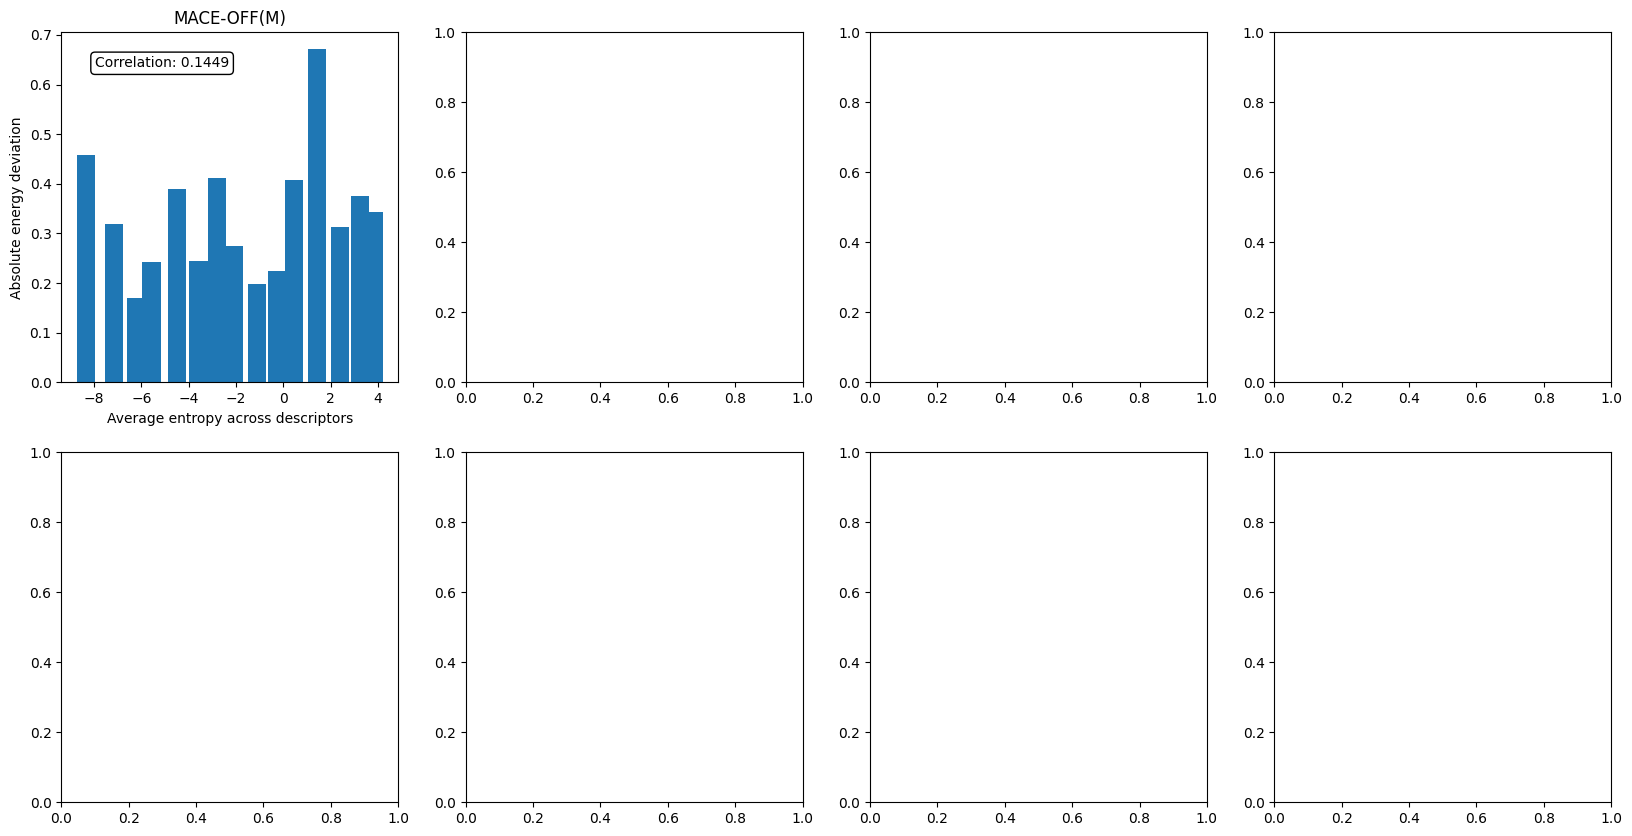

In [11]:
sim_entropies = avg_entropies

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
num_bins = 15  # or however many bins you want

for i, model_name in enumerate(model_names):
    energy_vals = np.abs(energy_cons[model_name])
    
    # Bin the sim_entropies
    bin_edges = np.linspace(min(sim_entropies), max(sim_entropies), num_bins + 1)
    bin_indices = np.digitize(sim_entropies, bins=bin_edges) - 1  # -1 for 0-based indexing

    binned_x = []
    binned_y = []

    for j in range(num_bins):
        mask = bin_indices == j
        if np.any(mask):
            binned_x.append(np.mean(sim_entropies[mask]))
            binned_y.append(np.mean(energy_vals[mask]))

    axs.flat[i].bar(
        binned_x, binned_y,
        width=(bin_edges[1] - bin_edges[0]) * 0.9,
        align='center',
        label="Binned averages"
    )

    axs.flat[i].set_xlabel("Average entropy across descriptors")
    axs.flat[i].set_ylabel("Absolute energy deviation")
    axs.flat[i].set_title(f"{model_name}")

    # correlation from raw data (not binned)
    corr, p_value = pearsonr(sim_entropies, energy_vals)
    axs.flat[i].text(0.1, 0.9, f"Correlation: {corr:.4f}", transform=axs.flat[i].transAxes,
                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))


## testing why the conservative models have high energy deviation

In [2]:
thresh = 3
sim_dir = '/home/christine/mlip-arena/simulations'
sim_folders = sorted(os.listdir(sim_dir))
in_thresh = {folder: [] for folder in sim_folders}
out_thresh = {folder: [] for folder in sim_folders}
for folder in sim_folders:
    if "DeepMD" in folder:
        continue
    for traj_file in sorted(os.listdir(os.path.join(sim_dir, folder))):
        traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
        
        # max distance between atoms at the beginning
        val_i = np.max(np.abs(np.roll(traj[0].get_positions(), 1, axis=0) - traj[0].get_positions()))
        
        # max distance between atoms at the end
        val_f = np.max(np.abs(np.roll(traj[-1].get_positions(), 1, axis=0) - traj[-1].get_positions()))
        
        # check if there's a significant difference between these two
        diff = abs(val_i - val_f)
        if diff < thresh:
            in_thresh[folder].append(traj_file)
        else:
            out_thresh[folder].append(traj_file)
    print(f"done with {folder}")

print("IN THRESH")
for key, value in in_thresh.items():
    print(f"{key}: {len(value)}")
print("\nOUT THRESH")
for key, value in out_thresh.items():
    print(f"{key}: {len(value)}")

done with CHGNet_MPTrj_sims_supercell_1000K
done with EquiformerV2(OC20)_OC20_sims_supercell_1000K
done with MACE-MP(M)_MPTrj_sims_supercell_1000K
done with MACE-MPA_MPTrj_sims_supercell_1000K
done with MACE-OFF(M)_spice_sims_supercell_1000K
done with MatterSim_MPTrj_sims_supercell_1000K
done with ORBv2_MPTrj_sims_supercell_1000K
done with SevenNet_MPTrj_sims_supercell_1000K
done with eSCN(OC20)_OC20_sims_supercell_1000K
done with eqV2(OMat)_MPTrj_sims_supercell_1000K
IN THRESH
CHGNet_MPTrj_sims_supercell_1000K: 43
DeepMD_MPTrj_sims_supercell_1000K: 0
EquiformerV2(OC20)_OC20_sims_supercell_1000K: 12
MACE-MP(M)_MPTrj_sims_supercell_1000K: 41
MACE-MPA_MPTrj_sims_supercell_1000K: 42
MACE-OFF(M)_spice_sims_supercell_1000K: 2
MatterSim_MPTrj_sims_supercell_1000K: 43
ORBv2_MPTrj_sims_supercell_1000K: 42
SevenNet_MPTrj_sims_supercell_1000K: 42
eSCN(OC20)_OC20_sims_supercell_1000K: 28
eqV2(OMat)_MPTrj_sims_supercell_1000K: 41

OUT THRESH
CHGNet_MPTrj_sims_supercell_1000K: 4
DeepMD_MPTrj_sims_s

## entropy along simulation

In [29]:
entropy_along_trajectory = np.load('mptrj_traj_eqV2(OMat)_MPTrj_sims_supercell_1000K_dH.npy', allow_pickle=True)

In [30]:
# need to separate this into the individual structures in the trajectory
entropy_along_trajectory.shape

(232848,)

In [31]:
sim_dir = '/home/christine/mlip-arena/simulations'
folder = 'eqV2(OMat)_MPTrj_sims_supercell_1000K'
structures = []
structures_idx = []
for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
    traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
    every_other = traj[2:49:2]
    structures.extend(every_other)
    structures_idx.extend([i] * 24)

In [32]:
len(structures)

1128

In [33]:
structures_idx[-1]

46

In [34]:
k, cutoff = 32, 5.0
result = []
for i, structure in enumerate(structures):
    y = get_descriptors([structure], k=k, cutoff=cutoff)
    result.extend([i] * len(y))

In [36]:
len(result)

232848

In [37]:
window_energy_cons = []
for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
    traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
    initials = traj[:48:2]
    finals = traj[4::2]
    energy_dev = [abs(initial.get_total_energy() - final.get_total_energy()) for initial, final in zip(initials, finals)]
    window_energy_cons.extend(energy_dev)

In [38]:
len(window_energy_cons)

1128

In [39]:
# using sum of each structure's descriptors' entropy
# Compute sum per index
subset_indices = np.array(result)
sum_entropy_per_index = np.bincount(subset_indices, weights=entropy_along_trajectory)

# Compute counts per index
counts = np.bincount(subset_indices)

# Avoid division by zero
avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

avg_entropies.shape

(1128,)

In [40]:
# need to remove these indices for chgnet
# idx_to_remove = np.array([ 2, 10, 15, 23, 25, 33, 34, 45])

# need to remove these for eqV2
idx_to_remove = np.array([ 2, 10, 25, 33, 34, 45])

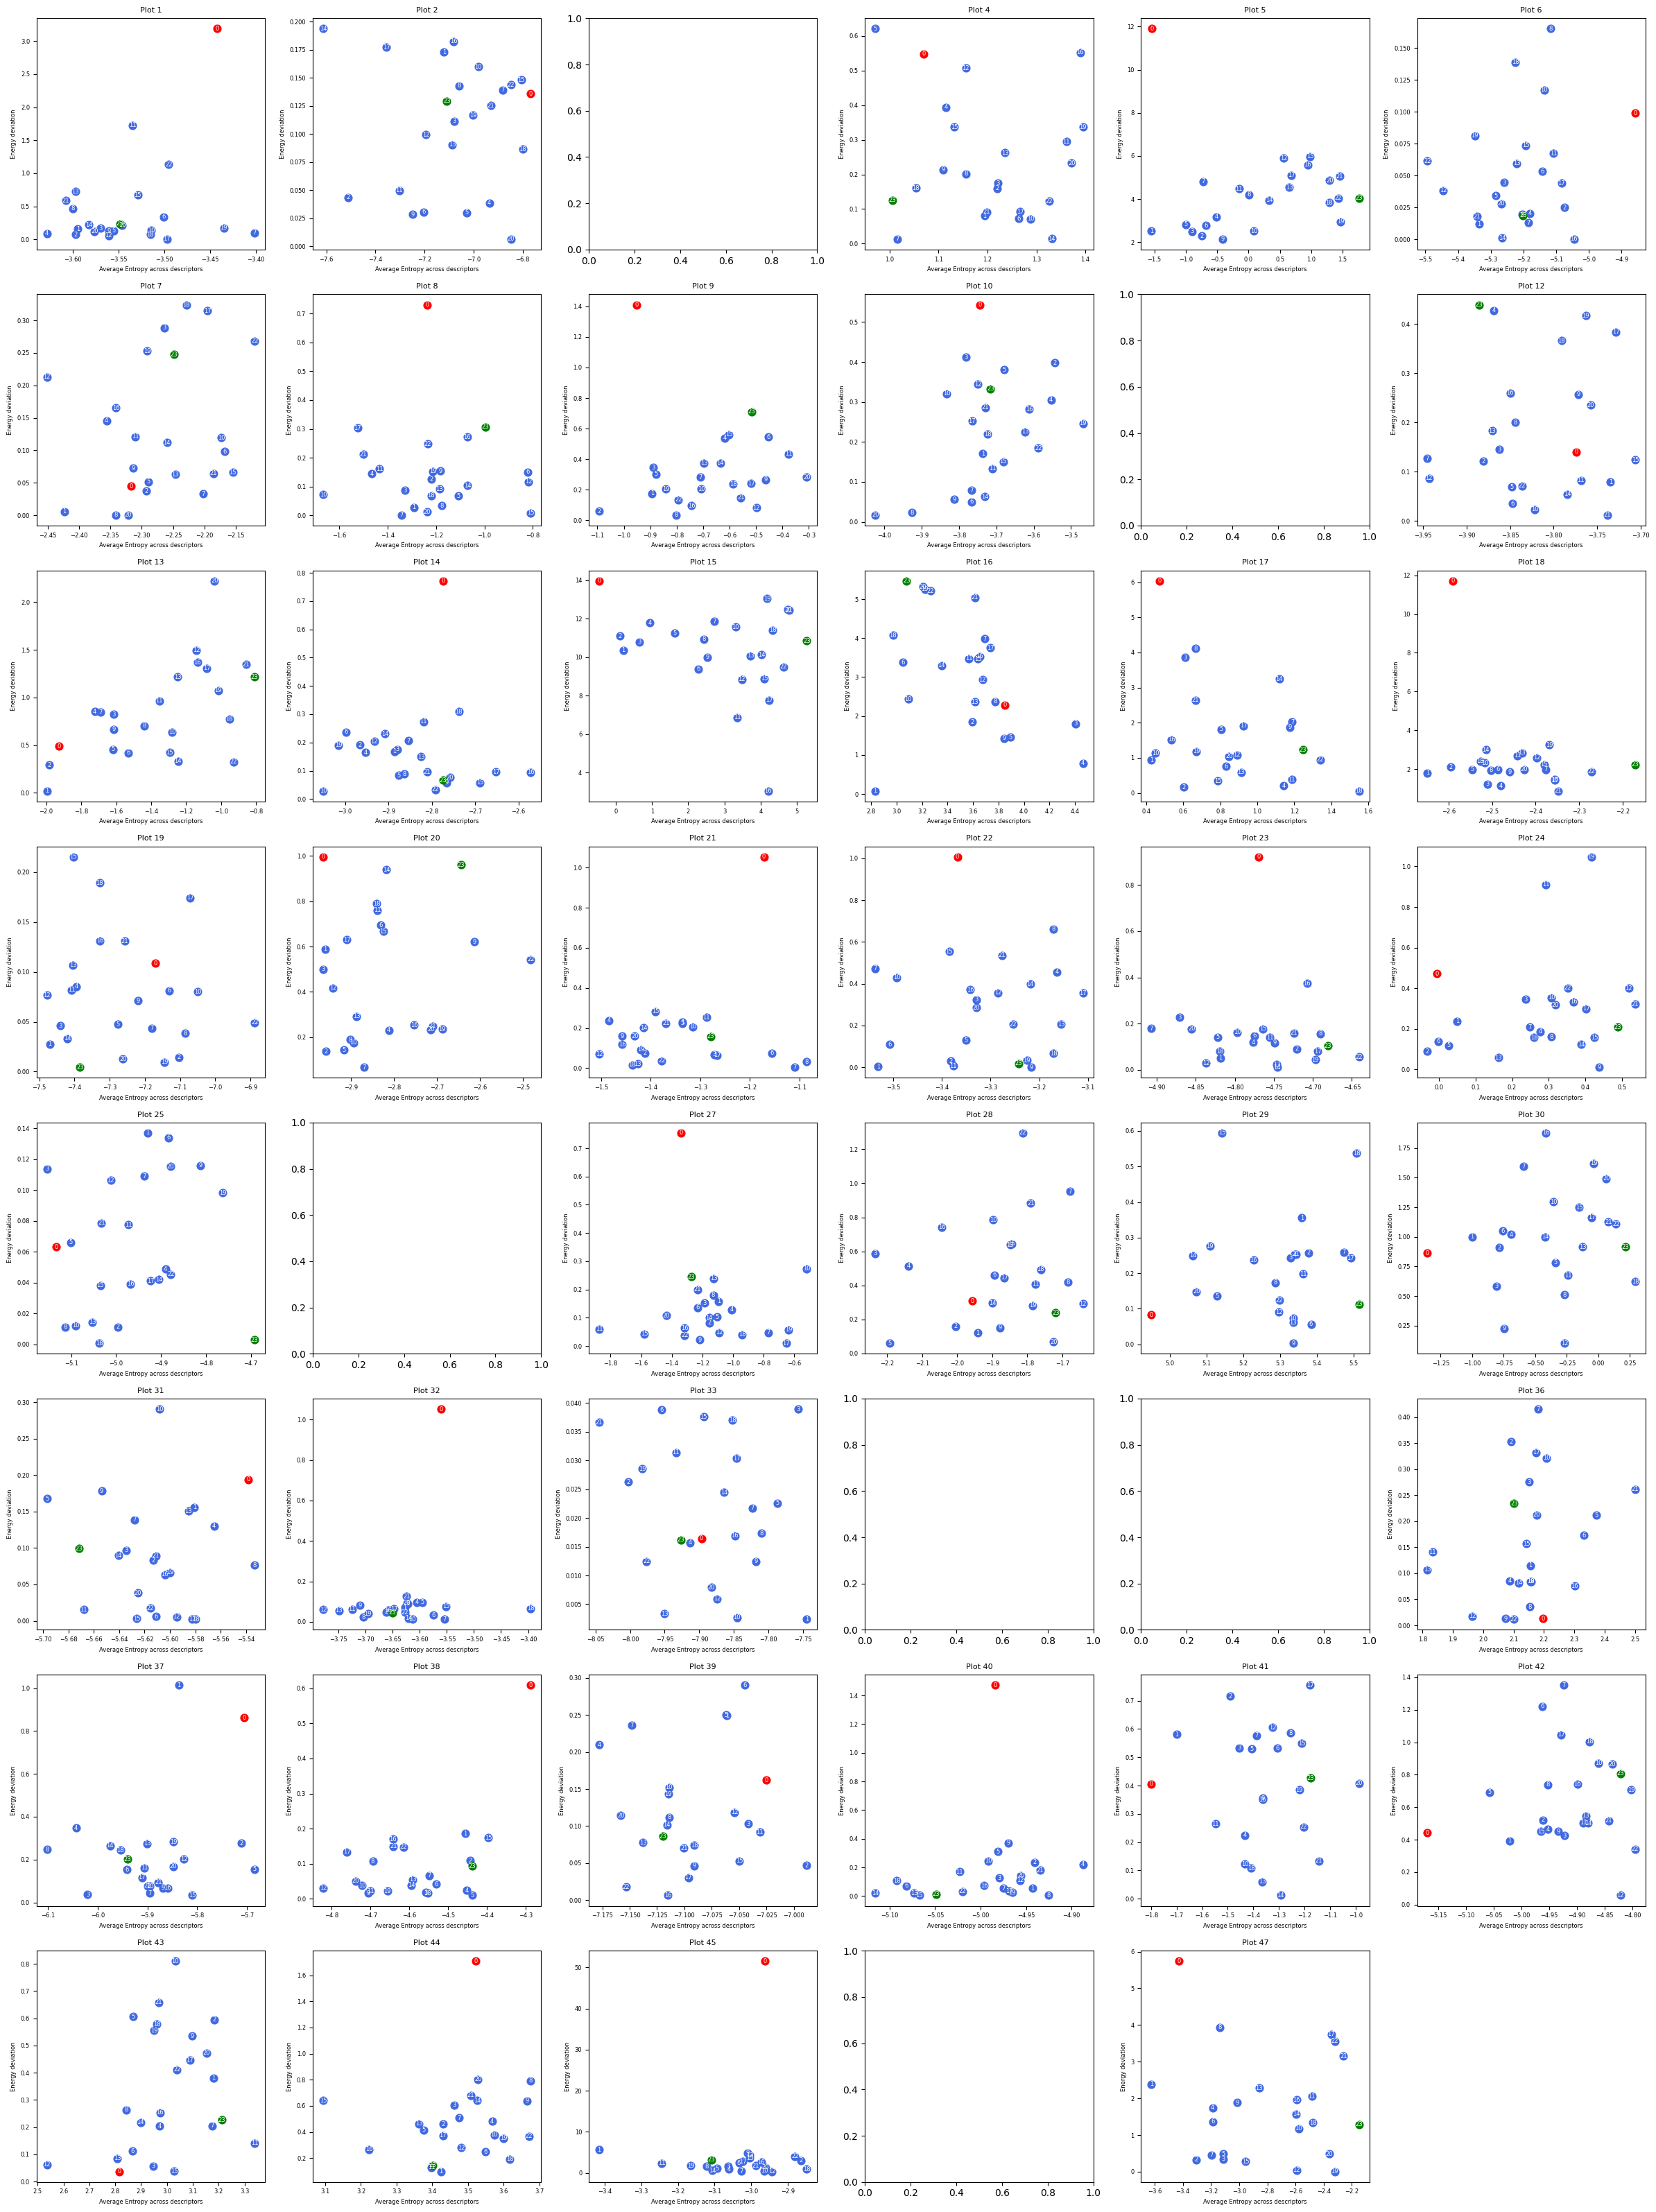

In [41]:
x = np.array(avg_entropies).reshape(47, 24)
y = np.array(window_energy_cons).reshape(47, 24)

fig, axes = plt.subplots(8, 6, figsize=(24, 32))  # adjust size as needed
axes = axes.flatten()

for i in range(47):
    if i in idx_to_remove:
        continue
    ax = axes[i]
    # ax.scatter(x[i], y[i], marker='o', color='royalblue', linewidth=1)
    ax.scatter(x[i, 1:23], y[i, 1:23], color='royalblue', s=60) # Middle points (j=1 to 22)
    ax.scatter(x[i, 0], y[i, 0], color='red', s=60, label='Start') # First point (j=0)
    ax.scatter(x[i, 23], y[i, 23], color='green', s=60, label='End') # Last point (j=23)
    for j in range(24):
        ax.annotate(str(j), (x[i, j], y[i, j]), fontsize=6, color='white', ha='center', va='center')
    ax.set_title(f'Plot {i+1}', fontsize=8)
    ax.set_xlabel('Average Entropy across descriptors', fontsize=6)
    ax.set_ylabel('Energy deviation', fontsize=6)
    ax.tick_params(axis='both', labelsize=6)
    # ax.grid(True)

# Hide the 48th (extra) subplot
axes[47].axis('off')

plt.tight_layout()
plt.show()

In [30]:
# get idxs_to_remove from above
idxs_to_remove

{'MACE-MP(M)': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'CHGNet': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'MatterSim': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'ORBv2': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'SevenNet': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'MACE-MPA': array([ 2, 10, 15, 23, 25, 33, 34, 45]),
 'eqV2(OMat)': array([ 2, 10, 15, 23, 25, 33, 34, 45])}

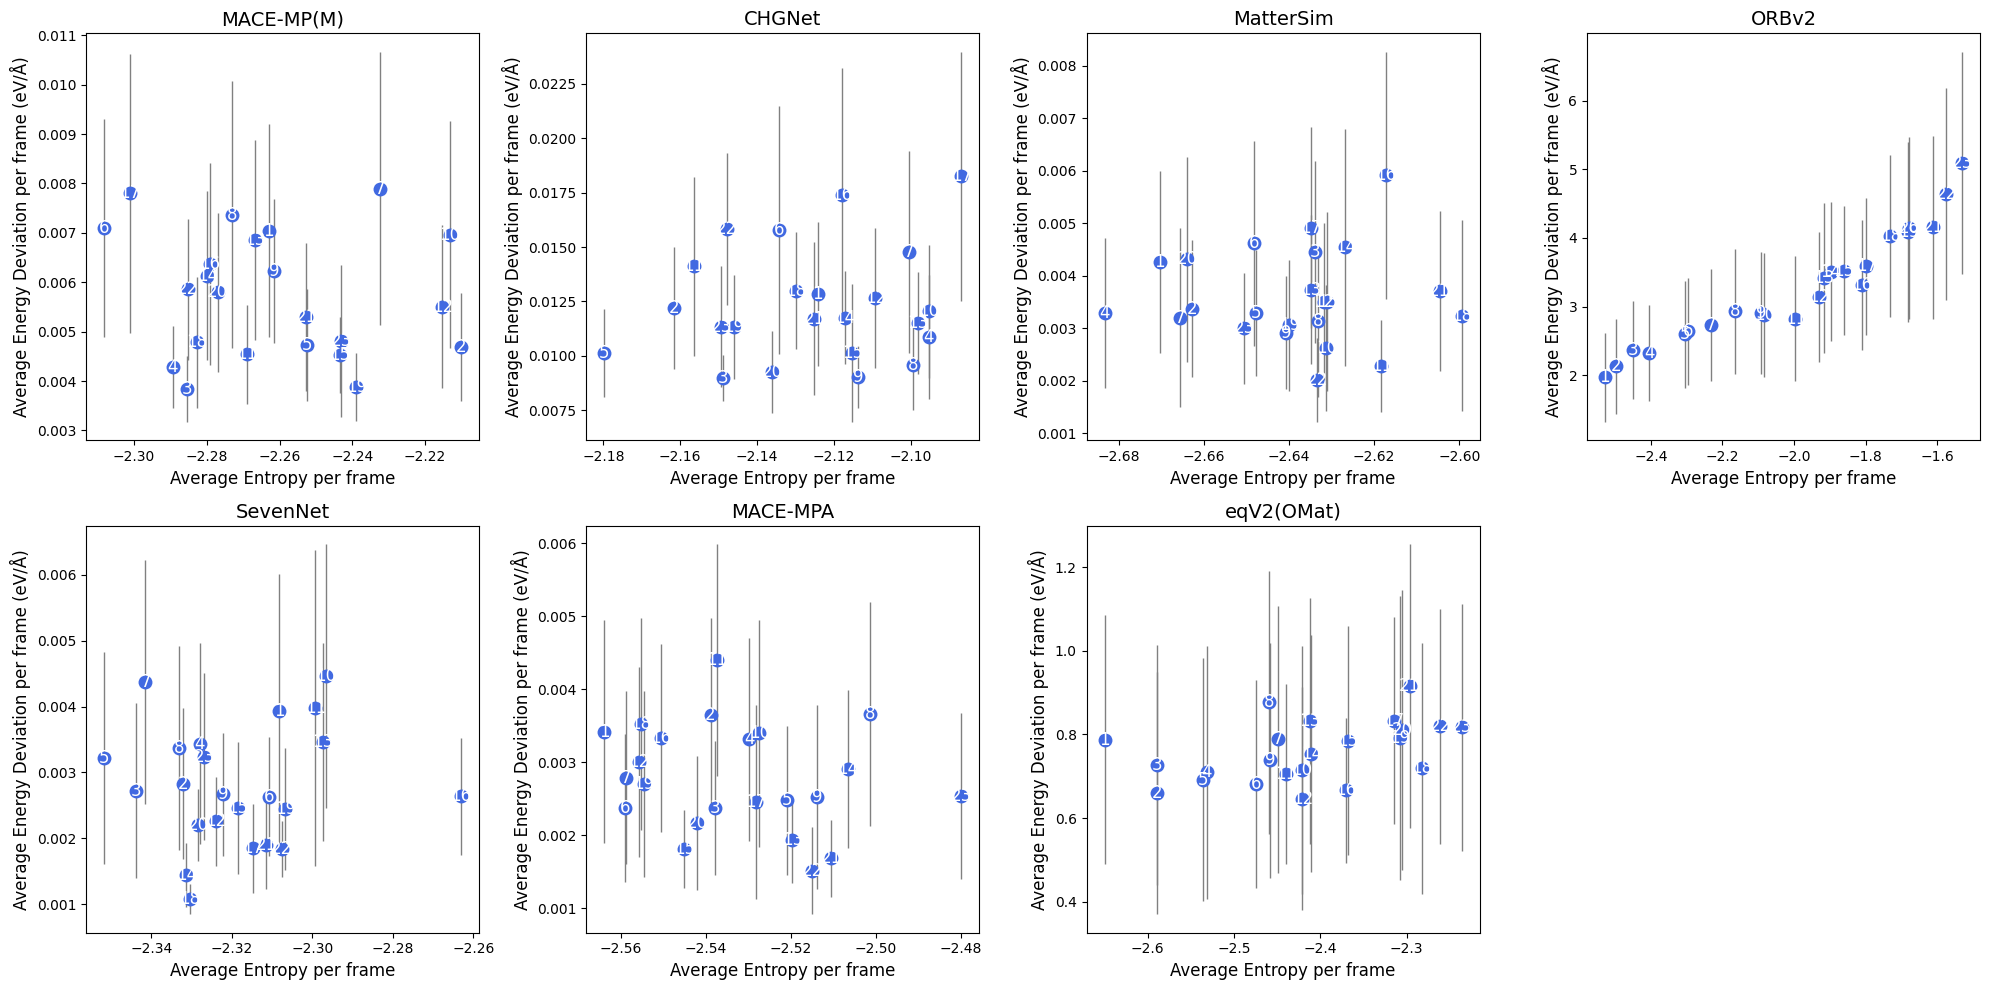

In [ ]:
# all in one cell
sim_dir = '/home/christine/mlip-arena/simulations'
model_names = ["MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "eqV2(OMat)"]
k, cutoff = 32, 5.0
result = []

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for model_num, model_name in enumerate(model_names):
    entropy_along_trajectory = np.load(f'mptrj_traj_{model_name}_MPTrj_sims_supercell_1000K_dH.npy', allow_pickle=True)
    folder = f'{model_name}_MPTrj_sims_supercell_1000K'
    structures = []
    structures_idx = []
    for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
        traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
        every_other = traj[2:49:2]
        structures.extend(every_other)
        structures_idx.extend([i] * 24)
        
    # bad coding practice but if i already ran this, then comment it out
    if model_num == 0:
        for i, structure in enumerate(structures):
            y = get_descriptors([structure], k=k, cutoff=cutoff)
            result.extend([i] * len(y))
            
    window_energy_cons = []
    for i, traj_file in enumerate(sorted(os.listdir(os.path.join(sim_dir, folder)))):
        traj = read(os.path.join(sim_dir, folder, traj_file), index=':')
        initials = traj[:48:2]
        finals = traj[4::2]
        energy_dev = [abs(initial.get_total_energy() - final.get_total_energy()) for initial, final in zip(initials, finals)]
        window_energy_cons.extend(energy_dev)
        
    # using sum of each structure's descriptors' entropy
    # Compute sum per index
    subset_indices = np.array(result)
    sum_entropy_per_index = np.bincount(subset_indices, weights=entropy_along_trajectory)
    counts = np.bincount(subset_indices)
    avg_entropies = np.divide(sum_entropy_per_index, counts, where=counts > 0)

    ax = axes[model_num]
    
    # Get indices to include (which trajectories are good/stable)
    valid_indices = [i for i in range(47) if i not in idxs_to_remove[model_name]]
    
    x = np.array(avg_entropies).reshape(47, 24)
    y = np.array(window_energy_cons).reshape(47, 24)

    # Stack only valid entries (shape: (num_valid, 24))
    x_valid = x[valid_indices]  # shape: (num_valid, 24)
    y_valid = y[valid_indices]  # shape: (num_valid, 24)
    
    # get rid of the first frame for each trajectory
    x_valid = x_valid[:, 1:]
    y_valid = y_valid[:, 1:]

    # Take average over axis 0 (across trajectories)
    avg_x = np.mean(x_valid, axis=0)  # shape: (23,) since we got rid of the first frame, or else it would be 24
    avg_y = np.mean(y_valid, axis=0)  # shape: (23,)

    # Create scatter plot
    # ax.scatter(avg_x, avg_y, color='royalblue', s=300)
    
    # Compute standard deviation across trajectories (axis=0)
    n_valid = x_valid.shape[0]  # should be ~47
    stderr_x = np.std(x_valid, axis=0) / np.sqrt(n_valid)
    stderr_y = np.std(y_valid, axis=0) / np.sqrt(n_valid)

    # Plot with error bars
    ax.errorbar(
        avg_x,
        avg_y,
        # xerr=stderr_x,
        yerr=stderr_y,
        fmt='o',
        ecolor='gray',
        elinewidth=1,
        capsize=3,
        markersize=10,
        markerfacecolor='royalblue',
        markeredgewidth=0
    )

    # Annotate with frame indices
    # texts = []
    for j in range(23):
        ax.annotate(str(j+1), (avg_x[j], avg_y[j]), fontsize=12, color='white', ha='center', va='center')
        # texts.append(txt)
        
    # adjust_text(
    #     texts,
    #     ax=ax,
    #     expand_text=(1.05, 1.05),         # Only expand a little bit
    #     expand_points=(1.05, 1.05),       # Keep labels close to points
    #     arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    #     force_text=0.2,                   # Keep movement small
    #     force_points=0.2,
    #     lim=100                           # Lower limit of iterations
    # )

    ax.set_xlabel("Average Entropy per frame", fontsize=12)
    ax.set_ylabel("Average Energy Deviation per frame (eV)", fontsize=12)
    ax.set_title(f"{model_name}", fontsize=14)
    
axes[7].axis('off')
    
plt.tight_layout()
plt.show()

## per-atom forces

In [38]:
random.seed(88)
data_dir = "/data/shared/MPTrj/original"
sample_size = 500
random_files = random_sample_from_directory(data_dir, sample_size)
num_structures_per_file = []
for file in random_files:
    atoms = read(os.path.join(data_dir, file), index=":")
    num_structures_per_file.append(len(atoms))

In [65]:
# from before, copied code. i should really organize this
dH = np.load('mptrj/mptrj_subset_dH.npy')
dH[np.isinf(dH)] = 0
subset_indices = np.load("mptrj/mptrj_subset_descriptor_indices.npy")
counts = np.bincount(subset_indices)
dset_y = read("mptrj/mptrj_subset_500.extxyz", index=":")

last_entropies = []
curr_index = 0
for item in num_structures_per_file:
    curr_index += item
    last_entropies.append(dH[(curr_index-1)*counts[curr_index-1]:curr_index*counts[curr_index-1]])
    
sim_entropies = last_entropies[::10]

In [66]:
for i in range(len(force_errors)):
    if len(sim_entropies[i]) != len(force_errors[i]):
        print(f"Mismatch at i={i}: sim={len(sim_entropies[i])}, force={len(force_errors[i])}")

Mismatch at i=16: sim=0, force=100
Mismatch at i=33: sim=0, force=112
Mismatch at i=41: sim=0, force=64
Mismatch at i=49: sim=0, force=56


In [68]:
# exclude these elements
indices_to_remove = [16, 33, 41, 49]
for idx in sorted(indices_to_remove, reverse=True):
    sim_entropies.pop(idx)

In [69]:
entropies_flat = np.concatenate(sim_entropies).ravel()
entropies_flat.shape

(1001,)

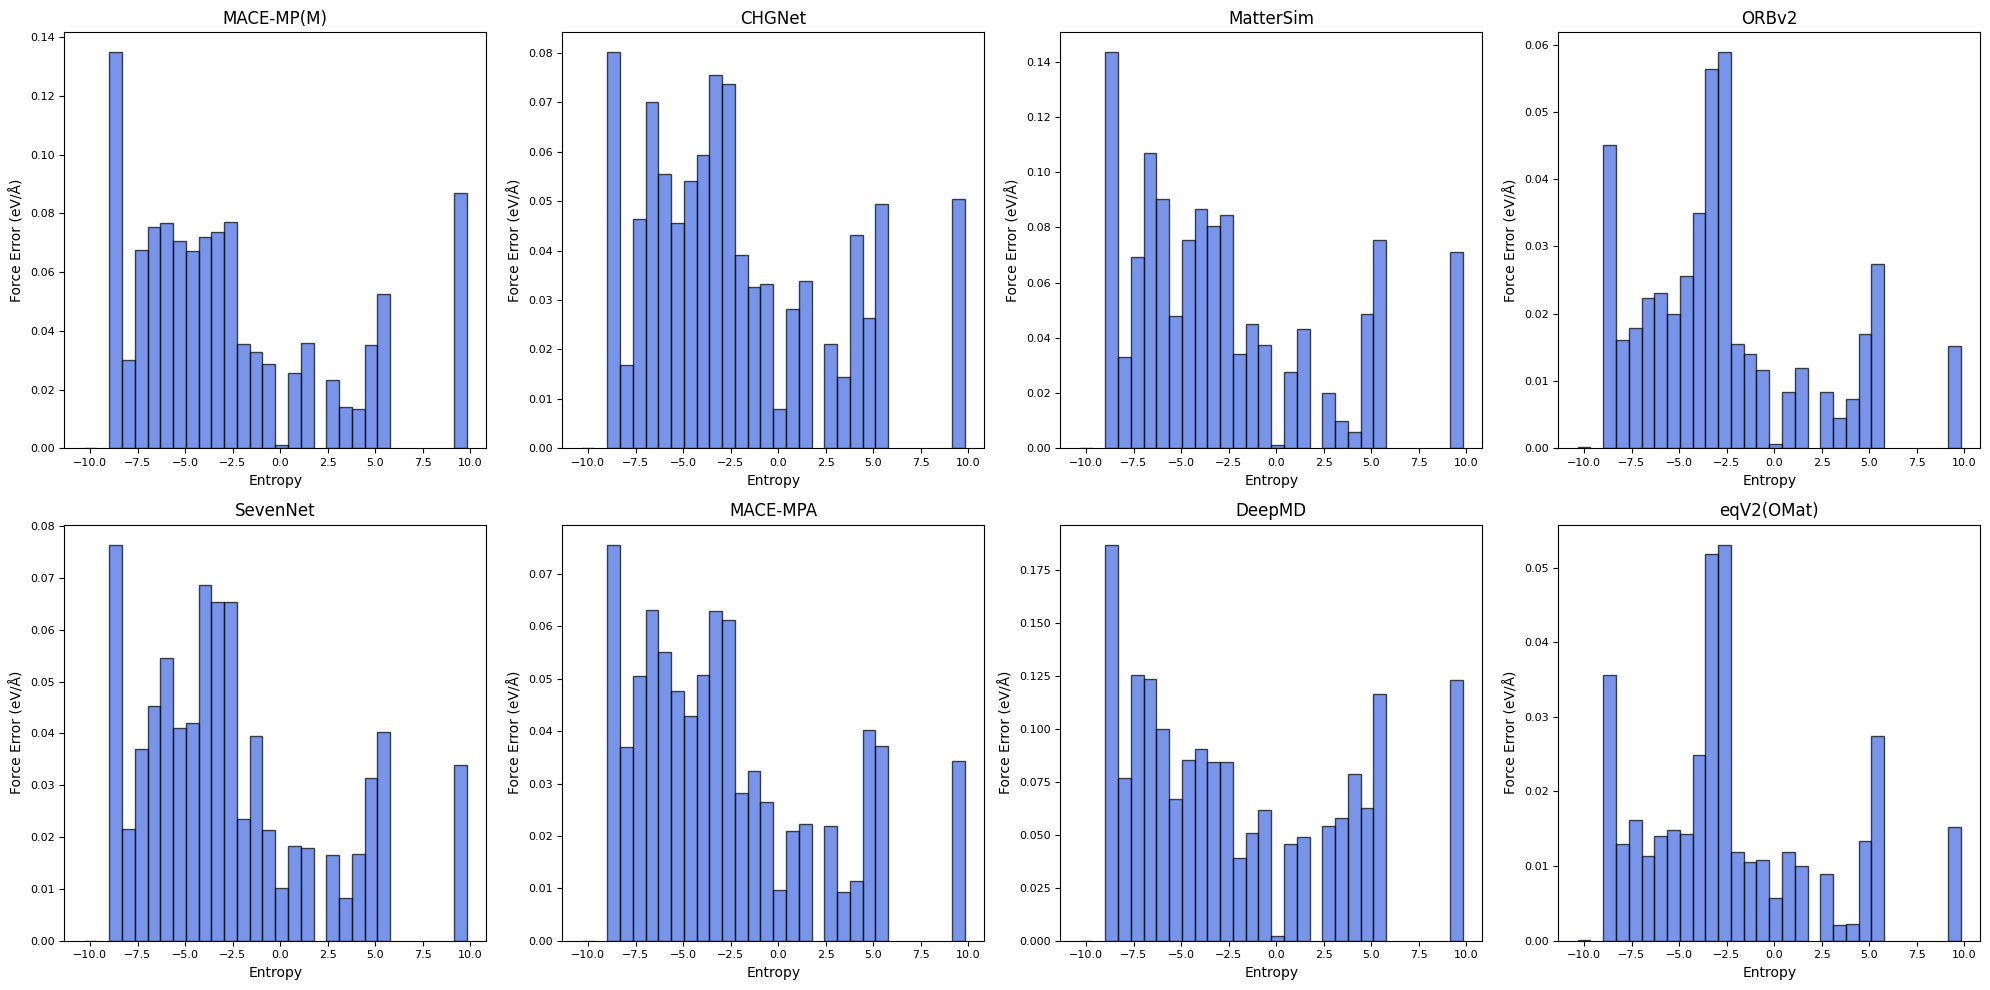

In [78]:
from scipy.stats import binned_statistic
model_names = ["MACE-MP(M)", "CHGNet", "MatterSim", "ORBv2", "SevenNet", "MACE-MPA", "DeepMD", "eqV2(OMat)"]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
n_bins = 30

for i, model_name in enumerate(model_names):
    force_errors = np.load(f'/home/christine/mlip-arena/force_errors_separate_50/{model_name}_force_errors.npy', allow_pickle=True)
    force_errors = np.delete(force_errors, indices_to_remove)
    fe_flat = np.concatenate(force_errors).ravel()
    assert(len(fe_flat) == len(entropies_flat))
    
    # Bin the data
    bin_means, bin_edges, _ = binned_statistic(entropies_flat, fe_flat, statistic='mean', bins=n_bins)
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plot bars
    ax = axes[i]
    ax.bar(bin_centers, bin_means, width=bin_width, color='royalblue', edgecolor='black', alpha=0.7)

    # Style
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Entropy", fontsize=10)
    ax.set_ylabel("Force Error (eV/Å)", fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()